In [1]:
import os

import matplotlib.pyplot as plt

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

import numpy as onp
import numpy.typing as npt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from typing import List, Callable, Tuple

from gridops import set_up_grid_axis
from gridops import create_anterpolation_function, make_restriction_operator, \
    make_prolongation_operator, create_interaction_operator

import sys

sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmfornn.splines.nesting import compute_J_zeroplus


In [2]:
p = 8
order = p - 1

# Construction of grids

In [3]:
length = 10.0
max_gridlevel = 4

grids_all_levels = [None]  # there is no grid at level zero
for l in range(1, max_gridlevel + 1):
    h = length / (2 ** (max_gridlevel - l))
    print(l, h)
    grid = set_up_grid_axis(length=length, h=h, p=p, periodic=False)
    grids_all_levels.append(grid)

1 1.25
2 2.5
3 5.0
4 10.0


In [4]:
grids_all_levels

[None,
 GridAxis1D(periodic=False, length=10.0, h=1.25, n_domain=9, n_total=17, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7f493f992a60>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7f493f992e50>),
 GridAxis1D(periodic=False, length=10.0, h=2.5, n_domain=5, n_total=13, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7f493f992af0>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7f493f9543a0>),
 GridAxis1D(periodic=False, length=10.0, h=5.0, n_domain=3, n_total=11, process_raw_indices=<function set_up_grid_axis.<locals>.process_raw_indices_nonperiodic at 0x7f493f9aa1f0>, get_gridindices_and_splinevals=<function set_up_grid_axis.<locals>.get_gridindices_and_splinevals at 0x7f493f954550>),
 GridAxis1D(periodic=False, length=10.0, h=10.0, n_domain=2, n_total=10, process_raw_indices=<f

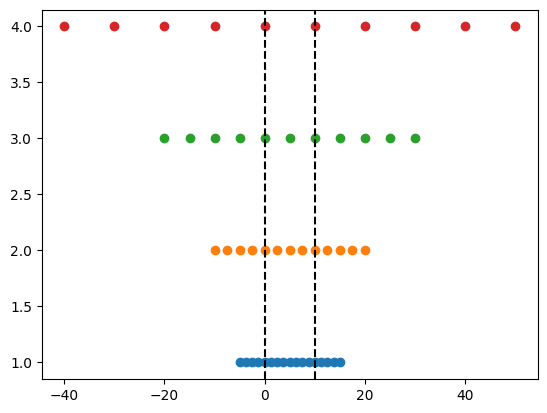

In [5]:
points_all_levels = [None]

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l, g in enumerate(grids_all_levels):
    if l == 0:
        continue
    points = (onp.arange(g.n_total) - p // 2) * g.h
    points_all_levels.append(points)
    ax.scatter(points, onp.zeros_like(points) + l)


In [6]:
def shift(m: npt.ArrayLike):
    return m - p // 2


def unshift(m: int):
    return m + p // 2

In [7]:
m_raw = 2
n_raw = shift(onp.arange(len(points_all_levels[1])))

In [8]:
n_raw

array([-4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [9]:
onp.abs(n_raw - 2 * m_raw)

array([8, 7, 6, 5, 4, 3, 2, 1, 0, 1, 2, 3, 4, 5, 6, 7, 8])

In [10]:
onp.abs(n_raw - 2 * m_raw) <= p // 2

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False])

In [11]:
onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)[0]

array([ 4,  5,  6,  7,  8,  9, 10, 11, 12])

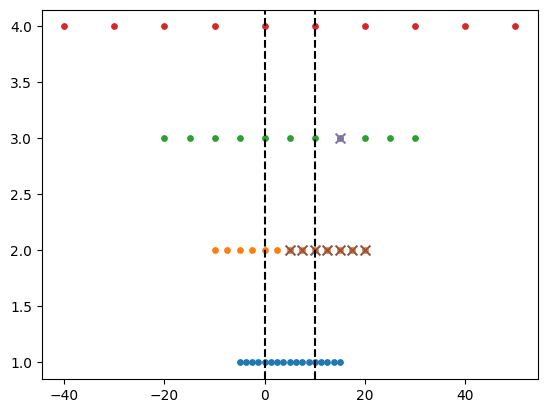

In [12]:
fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')

for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

l = 3
m_raw = 3
n_raw = shift(onp.arange(len(points_all_levels[l - 1])))
is_in_bounds = onp.where(onp.abs(n_raw - 2 * m_raw) <= p // 2)
n_raw_selected = n_raw[is_in_bounds]

ax.scatter(points_all_levels[l][unshift(m_raw)], l, marker="x", s=50)
ax.scatter(points_all_levels[l - 1][unshift(n_raw_selected)],
           onp.full_like(n_raw_selected, l - 1), marker="x", s=50)

# Restriction

In [13]:
J_zeroplus = compute_J_zeroplus(p)
J = onp.concatenate((J_zeroplus[::-1][:-1], J_zeroplus))
J

array([0.0078125, 0.0625   , 0.21875  , 0.4375   , 0.546875 , 0.4375   ,
       0.21875  , 0.0625   , 0.0078125])

In [14]:
n_particles = 15

rng = onp.random.default_rng(8439293)
xs = rng.uniform(0., length, size=n_particles)
qs = rng.uniform(-1., 1., size=n_particles)

## Compare grid charges computed via restriction with directly computed ones

In [15]:
anterpolation_funcs_all_levels = [None] + [
    jax.jit(create_anterpolation_function(g)) for g in grids_all_levels[1:]]

restriction_funcs_all_levels = [None, None]
for l in range(2, len(grids_all_levels)):
    rf = make_restriction_operator(grid_source=grids_all_levels[l - 1],
                                   grid_target=grids_all_levels[l], J=J)
    rf = jax.jit(rf)
    restriction_funcs_all_levels.append(rf)

In [16]:
# TODO
# gridcharges_direct = [None] + [af(xs, qs)[0] for af in
#                                anterpolation_funcs_all_levels[1:]]
# 
# gridcharges_via_restriction = [None, None]
# for l in range(2, len(grids_all_levels)):
#     rf = restriction_funcs_all_levels[l]
#     gc_lowergrid = gridcharges_direct[l - 1]
#     gc = rf(gc_lowergrid)
#     gridcharges_via_restriction.append(gc)

In [17]:
gridcharges_direct = [None] + [af(xs, qs)[0] for af in
                               anterpolation_funcs_all_levels[1:]]

gridcharges_via_restriction = [None, gridcharges_direct[1]]
for l in range(2, len(grids_all_levels)):
    rf = restriction_funcs_all_levels[l]
    gc_lowergrid = gridcharges_via_restriction[l - 1]
    gc = rf(gc_lowergrid)
    gridcharges_via_restriction.append(gc)

In [18]:
for gc_direct, gc_restrict in zip(gridcharges_direct[2:],
                                  gridcharges_via_restriction[2:]):
    assert jnp.allclose(gc_direct, gc_restrict)

# Test jitting of anterpolation + loop over restriction at all grid levels in single function

In [19]:
def create_anterpolate_and_restrict(grids_all_levels,
                                    J: npt.ArrayLike) -> Callable:
    anterpolate = create_anterpolation_function(grids_all_levels[1])

    restriction_funcs_all_levels = [None, None]
    for lvl in range(2, len(grids_all_levels)):
        rf = make_restriction_operator(grid_source=grids_all_levels[lvl - 1],
                                       grid_target=grids_all_levels[lvl], J=J)
        restriction_funcs_all_levels.append(rf)

    def anterpolate_and_restrict(positions: jax.Array,
                                 charges: jax.Array) -> List:
        gridcharge_level_one, _, _ = anterpolate(positions_1d=positions,
                                                 charges=charges)
        gridcharges_all_levels = [None, gridcharge_level_one]
        for lvl in range(2, len(grids_all_levels)):
            rf = restriction_funcs_all_levels[lvl]
            gc_lowergrid = gridcharges_all_levels[lvl - 1]
            gc = rf(gc_lowergrid)
            gridcharges_all_levels.append(gc)

        return gridcharges_all_levels

    return anterpolate_and_restrict

In [20]:
anterpolate_and_restrict = create_anterpolate_and_restrict(grids_all_levels, J)
jitted_anterpolate_and_restrict = jax.jit(anterpolate_and_restrict)

In [21]:
jitted_anterpolate_and_restrict(xs, qs)

[None,
 Array([ 0.00000000e+00,  1.83374696e-04,  2.41852797e-02,  2.85980886e-01,
         9.07023298e-01,  1.17070121e+00,  9.20908606e-01,  5.97616749e-01,
         3.80868871e-02,  4.43103550e-02,  2.97584891e-01, -3.21452569e-01,
        -4.54071334e-01, -1.02526792e-01, -3.79534960e-03, -2.83815915e-06,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.00408416e-04,  3.03306813e-02,  4.17197959e-01,
         1.37772613e+00,  1.50716088e+00,  6.24834054e-01, -1.13965096e-02,
        -3.66477996e-01, -1.64026303e-01, -1.07868312e-02, -2.98285537e-05,
         0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  2.49483973e-04,  4.35608731e-02,  5.99655539e-01,
         1.73510539e+00,  1.23328948e+00, -3.78831280e-02, -1.53671433e-01,
        -1.54874226e-02, -8.61364035e-05,  0.00000000e+00], dtype=float64),
 Array([ 0.00000000e+00,  3.55912069e-04,  6.06720723e-02,  7.42619735e-01,
         1.74233135e+00,  8.65595398e-01,  6.61054825e-03, -1.33259849e-0

# Prolongation

In [22]:
J_rolled = onp.roll(J, (len(J) - 1) // 2 + 1)

ns_raw = jnp.arange(-10, 15)

for m_raw in range(0, 10):
    m_minus_2n = m_raw - 2 * ns_raw
    cond = jnp.abs(m_minus_2n) <= p / 2
    inds_into_J = m_minus_2n[cond]
    print(m_raw, cond.sum(), inds_into_J, J_rolled[inds_into_J])

0 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
1 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
2 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
3 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
4 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
5 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
6 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
7 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]
8 5 [ 4  2  0 -2 -4] [0.0078125 0.21875   0.546875  0.21875   0.0078125]
9 4 [ 3  1 -1 -3] [0.0625 0.4375 0.4375 0.0625]


In [23]:
def find_raw_ns_by_ceil_floor(m_raw):
    if m_raw % 2 == 0:
        start = int(onp.ceil(onp.round(-p / 4, decimals=1)))
        end = int(onp.floor(onp.round(p / 4, decimals=1)))
    else:
        start = int(onp.ceil(onp.round(0.5 - p / 4, decimals=1)))
        end = int(onp.floor(onp.round(0.5 + p / 4, decimals=1)))

    return m_raw // 2 + jnp.arange(start, end + 1), start, end

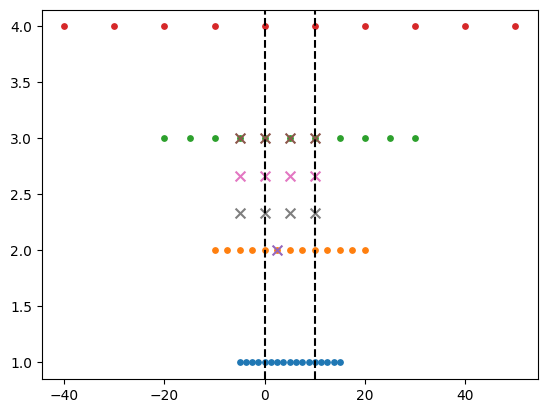

In [24]:
lvl = 2
m_raw = 1

fig, ax = plt.subplots()
ax.axvline(0, color='k', linestyle='--')
ax.axvline(length, color='k', linestyle='--')
for l in range(1, max_gridlevel + 1):
    g = grids_all_levels[l]
    points = points_all_levels[l]
    ax.scatter(points, onp.full_like(points, l), s=15)

ax.scatter(points_all_levels[lvl][unshift(m_raw)], lvl, marker="x", s=50)

# find contributing points by applying comparison
ns_raw = shift(onp.arange(len(points_all_levels[lvl + 1])))
m_minus_2n = m_raw - 2 * ns_raw
cond = jnp.abs(m_minus_2n) <= p // 2
ns_raw_selected = ns_raw[cond]

ax.scatter(points_all_levels[lvl + 1][unshift(ns_raw_selected)],
           onp.full_like(ns_raw_selected, lvl + 1), marker="x", s=50)

# find contributing points by explicit expression
if p % 4 == 0:
    extra = 0
else:
    extra = 1
start = m_raw // 2 - p // 4
end = m_raw // 2 + p // 4
if m_raw % 2 == 0:
    raw_n_range = jnp.arange(start, end + 1)
else:
    raw_n_range = jnp.arange(start + 1 - extra, end + extra + 1)

ax.scatter(points_all_levels[lvl + 1][unshift(raw_n_range)],
           onp.full_like(raw_n_range, lvl + 1 - 0.3333, dtype=float),
           marker="x", s=50)

# find by ceil/floor
raw_ns_by_ceil_floor, start, end = find_raw_ns_by_ceil_floor(m_raw)
ax.scatter(points_all_levels[lvl + 1][unshift(raw_ns_by_ceil_floor)],
           onp.full_like(raw_ns_by_ceil_floor, lvl + 1 - 0.6666, dtype=float),
           marker="x", s=50)

assert onp.array_equal(ns_raw_selected, raw_n_range)
assert onp.array_equal(ns_raw_selected, raw_ns_by_ceil_floor)

In [25]:
lvl = 1

prolongate = make_prolongation_operator(
    grid_source=grids_all_levels[lvl + 1],
    grid_target=grids_all_levels[lvl],
    p=p,
    J_zeroplus=J_zeroplus,
)
jitted_prolongate = jax.jit(prolongate)

In [26]:
prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.11865647,  0.28191419,  0.54794382,  0.88137251,  1.17951595,
        1.32726507,  1.26545897,  1.01814339,  0.67680496,  0.33967161,
        0.06077616, -0.13651961, -0.23399415, -0.23348209, -0.17231783,
       -0.09938749, -0.04464944], dtype=float64)

In [27]:
jitted_prolongate(array_coarse=gridcharges_direct[lvl + 1])

Array([ 0.11865647,  0.28191419,  0.54794382,  0.88137251,  1.17951595,
        1.32726507,  1.26545897,  1.01814339,  0.67680496,  0.33967161,
        0.06077616, -0.13651961, -0.23399415, -0.23348209, -0.17231783,
       -0.09938749, -0.04464944], dtype=float64)

## Check against explicit matrix multiplication

In [28]:
def get_entry_of_J(idx):
    if onp.abs(idx) > p // 2:
        return 0.
    else:
        return J_zeroplus[abs(idx)]

In [29]:
I_21 = onp.zeros((grids_all_levels[2].n_total, grids_all_levels[1].n_total))
for m in range(I_21.shape[0]):
    for n in range(I_21.shape[1]):
        m_raw = m - p // 2
        n_raw = n - p // 2
        I_21[m, n] = get_entry_of_J(n_raw - 2 * m_raw)

I_12 = I_21.T

In [30]:
I_21

array([[0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.21875  , 0.0625   , 0.0078125, 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.546875 , 0.4375   , 0.21875  , 0.0625   , 0.0078125, 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.21875  , 0.4375   , 0.546875 , 0.4375   , 0.21875  , 0.0625   ,
        0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       ],
       [0.0078125, 0.0625   , 0.21875  , 0.4375   , 0.546875 , 0.4375   ,
        0.21875  , 0.0625   , 0.0078125, 0.       , 0.       , 0.       ,
    

In [31]:
I_12

array([[0.0078125, 0.21875  , 0.546875 , 0.21875  , 0.0078125, 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.0625   , 0.4375   , 0.4375   , 0.0625   , 0.       ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.0078125, 0.21875  , 0.546875 , 0.21875  , 0.0078125,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.0625   , 0.4375   , 0.4375   , 0.0625   ,
        0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.0078125, 0.21875  , 0.546875 , 0.21875  ,
        0.0078125, 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , 0.0625   , 0.4375   , 0.4375   ,
        0.0625   , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.  

In [32]:
# Compare restriction operator with explicit matrix multiplication
# (This is arguably redundant for testing the restriction operator, but it shows
# us whether we have correctly set up the I matrix, which we'll use again below)
assert jnp.allclose(I_21 @ gridcharges_direct[1], gridcharges_direct[2])

# Compare prolongation operator with explicit matrix multiplication
assert jnp.allclose(I_12 @ gridcharges_direct[2],
                    prolongate(gridcharges_direct[2]))

# Interaction

In [33]:
kernelstencil = jnp.array([0.5, 1., 2., 4., 2., 1., 0.5])
lvl = 1

apply_interaction = create_interaction_operator(grids_all_levels[lvl],
                                                kernelstencil)
jitted_apply_interaction = jax.jit(apply_interaction)

In [34]:
jitted_apply_interaction(gridcharges_direct[lvl])

Array([ 0.16754247,  0.78859659,  2.16144354,  4.63767958,  7.78545132,
        9.25340235,  8.33052614,  6.12577364,  3.07931957,  1.35816779,
        0.46761567, -1.63985383, -2.34830076, -1.4985035 , -0.83503828,
       -0.33716451, -0.05506442], dtype=float64)

## Check against numpy convolution function

In [35]:
assert onp.allclose(
    apply_interaction(gridcharges_direct[lvl]),
    onp.convolve(gridcharges_direct[lvl], kernelstencil, mode="same"),
)

# Full grid potential computation + test jitting

In [36]:
# def create_compute_gridpotential_level_one(
#         grids,
#         kernelstencils,
#         J: npt.ArrayLike,
#         return_spline_gradients: bool = False,
# ) -> Callable:
#     J_zeroplus = J[len(J) // 2 :]  # TODO: pass J or J_zeroplus?
#     p = len(J) - 1  # TODO: How should p be passed/inferred?
# 
#     max_gridlevel = len(grids) - 1
# 
#     anterpolate = create_anterpolation_function(grids[1], return_spline_gradients=return_spline_gradients)
# 
#     restriction_funcs = {}
#     for lvl in range(2, max_gridlevel + 1):
#         restrict = make_restriction_operator(
#             grid_source=grids[lvl - 1], grid_target=grids[lvl], J=J
#         )
#         restriction_funcs[lvl] = restrict
# 
#     prolongation_funcs = {}
#     for lvl in range(1, max_gridlevel):
#         prolongate = make_prolongation_operator(
#             grid_source=grids[lvl + 1],
#             grid_target=grids[lvl],
#             J_zeroplus=J_zeroplus,
#             p=p,
#         )
#         prolongation_funcs[lvl] = prolongate
# 
#     interaction_funcs = {}
#     for lvl in range(1, max_gridlevel + 1):
#         interact = create_interaction_operator(
#             grid=grids[lvl], kernelstencil=kernelstencils[lvl]
#         )
#         interaction_funcs[lvl] = interact
# 
#     def compute_gridpotential_level_one(
#         positions: jax.Array, charges: jax.Array
#     ) -> Tuple[jax.Array, jax.Array, jax.Array]:
#         # Compute lowest-level grid charge from particle positions and charges
#         gridcharge_level_one, indices, spline_outputs = anterpolate(
#             positions_1d=positions, charges=charges
#         )
#         gridcharges_all_levels = {1: gridcharge_level_one}
# 
#         # Go up ladder
#         for lvl in range(2, max_gridlevel + 1):
#             restrict = restriction_funcs[lvl]
#             gridcharge_fine = gridcharges_all_levels[lvl - 1]
#             gridcharge_coarse = restrict(gridcharge_fine)
#             gridcharges_all_levels[lvl] = gridcharge_coarse
# 
#         # Apply top-level interaction
#         gridcharge_toplevel = gridcharges_all_levels[max_gridlevel]
#         interaction_toplevel = interaction_funcs[max_gridlevel]
#         gridpotential = interaction_toplevel(gridcharge_toplevel)
# 
#         # Go down ladder
#         for lvl in range(max_gridlevel - 1, 0, -1):
#             gridpotential = interaction_funcs[lvl](
#                 gridcharges_all_levels[lvl]
#             ) + prolongation_funcs[lvl](gridpotential)
# 
#         return gridpotential, indices, spline_outputs
# 
#     return compute_gridpotential_level_one


In [37]:
# kernelstencils_old_loaded = onp.load("precomputed_kernelstencils_old/kernelstencils.npz")
# 
# stencils = [None]
# for k in kernelstencils_old_loaded.keys():
#     print(k)
#     stencils.append(kernelstencils_old_loaded[k])
#     
# stencils_loaded_symmetric = [None]
# for stncl in stencils[1:]:
#     stncl_symm = jnp.concatenate((stncl[-1:0:-1], stncl))
#     stencils_loaded_symmetric.append(stncl_symm)

In [38]:
# compute_gridpotential_level_one = create_compute_gridpotential_level_one(
#     grids=grids_all_levels,
#     kernelstencils=stencils_loaded_symmetric,
#     J=J,
# )
# jitted_compute_gridpotential_level_one = jax.jit(compute_gridpotential_level_one)

In [39]:
# gridpotential_level_one, indices, splinevals = compute_gridpotential_level_one(positions, charges)

In [40]:
# jitted_compute_gridpotential_level_one(positions, charges)

# Interpolation

In [41]:
sys.path.append("/home/florian/PhD/work/code/msm_for_nn/")

from msmjax.kernels import SofteningFunctionOneOverR, split_one_over_r_kernel
from msmfornn.gridtools import construct_grids_all_levels
from msmfornn.splines.coefficients import compute_coeffs_withtruncation
from msmfornn.grid_to_grid_mapping import compute_kernel_stencils_all_gridlevels

In [42]:
level_one_gridspacing = 1.25
alpha = 3
level_zero_cutoff = alpha * level_one_gridspacing

params_oldmsm = {
    "min_pos": onp.array([0.]),
    "max_pos": onp.array([length]),
    "level_one_gridspacing": grids_all_levels[1].h,
    "level_zero_cutoff": level_zero_cutoff,
    "max_gridlevel": max_gridlevel,
    "p": p,
    "mu": 3
}

grids_oldmsm = construct_grids_all_levels(
    min_pos=params_oldmsm["min_pos"],
    max_pos=params_oldmsm["max_pos"],
    p=params_oldmsm["p"],
    level_one_gridspacing=params_oldmsm["level_one_gridspacing"],
    max_gridlevel=params_oldmsm["max_gridlevel"],
)
partial_kernels = split_one_over_r_kernel(
    max_level=max_gridlevel,
    level_zero_cutoff=level_zero_cutoff,
    softening_function=SofteningFunctionOneOverR(p),
)
omega, _ = compute_coeffs_withtruncation(p=params_oldmsm["p"], mu=params_oldmsm["mu"])
omega_zeroplus = omega[len(omega) // 2 : ]

kernelstencils_old = compute_kernel_stencils_all_gridlevels(
    kernelfunctions=partial_kernels,
    grids=grids_oldmsm,
    level_zero_cutoff=level_zero_cutoff,
    omega_zeroplus=omega_zeroplus,
)
kernelstencils_old_symmetric = [None]
for stncl in kernelstencils_old[1:]:
    stncl_symm = jnp.concatenate((stncl[-1:0:-1], stncl))
    kernelstencils_old_symmetric.append(stncl_symm)

In [43]:
from gridops import create_compute_gridpotential_level_one

compute_gridpotential_level_one = create_compute_gridpotential_level_one(
    grids=grids_all_levels,
    kernelstencils=kernelstencils_old_symmetric,
    J=J,
)
jitted_compute_gridpotential_level_one = jax.jit(compute_gridpotential_level_one)

In [44]:
gridpotential_level_one, indices, spline_outputs = jitted_compute_gridpotential_level_one(positions=xs, charges=qs)
splinevals = spline_outputs[0]

U_oneplus_from_grids = 0.5 * (qs[:, jnp.newaxis] * gridpotential_level_one[indices] * splinevals).sum()

In [45]:
def sum_kernels_1_to_L(r):
    return jnp.sum(jnp.asarray([k(r) for k in partial_kernels[1:]]))

jitted_sum_kernels_1_to_L = jax.jit(sum_kernels_1_to_L)

U_oneplus_direct = 0.
for i in range(len(xs)):
    for j in range(0, len(xs)):
        r_ij = jnp.linalg.norm(xs[i] - xs[j])
        U_oneplus_direct += qs[i] * qs[j] * jitted_sum_kernels_1_to_L(r_ij)
        
U_oneplus_direct *= 0.5

In [46]:
def compute_U_oneplus_direct_vectorized(positions, charges):
    r_ij = jnp.abs(positions[:, jnp.newaxis] - positions)
    q_i_times_q_j = charges[:, jnp.newaxis] * charges
    
    return 0.5 * (q_i_times_q_j * jax.vmap(jax.vmap(sum_kernels_1_to_L))(r_ij)).sum()

In [47]:
jitted_compute_U_oneplus_direct_vectorized = jax.jit(compute_U_oneplus_direct_vectorized)

In [48]:
jitted_compute_U_oneplus_direct_vectorized(xs, qs)

Array(5.17803384, dtype=float64)

In [49]:
U_oneplus_from_grids, U_oneplus_direct

(Array(5.13967242, dtype=float64), Array(5.17803384, dtype=float64))

In [50]:
k_prime = jax.grad(sum_kernels_1_to_L)
jitted_k_prime = jax.jit(k_prime)

f_oneplus_direct = []
for i in range(len(xs)):
    force = 0.
    for j in range(len(xs)):
        if i == j:
            continue
        x_i_minus_x_j = xs[i] - xs[j]
        r_ij = jnp.abs(x_i_minus_x_j)
        force -= qs[j] * (x_i_minus_x_j / r_ij) * jitted_k_prime(r_ij)
    force *= qs[i]
    f_oneplus_direct.append(force)
    
f_oneplus_direct = jnp.array(f_oneplus_direct)

In [51]:
f_oneplus_direct

Array([-0.1143676 ,  0.38805495,  0.46177005,  0.26493242, -0.15524232,
       -0.48710806, -0.17381324, -0.1656056 ,  0.04486804,  0.27504372,
       -0.08193898, -0.08098226, -0.02873972, -0.09875555, -0.04811585],      dtype=float64)

In [52]:
def compute_f_oneplus_direct_vectorized(positions, charges):
    return - jax.grad(compute_U_oneplus_direct_vectorized, argnums=0)(positions, charges) 

jitted_compute_f_oneplus_direct_vectorized = jax.jit(compute_f_oneplus_direct_vectorized)

In [53]:
jitted_compute_f_oneplus_direct_vectorized(xs, qs)

Array([-0.1143676 ,  0.38805495,  0.46177005,  0.26493242, -0.15524232,
       -0.48710806, -0.17381324, -0.1656056 ,  0.04486804,  0.27504372,
       -0.08193898, -0.08098226, -0.02873972, -0.09875555, -0.04811585],      dtype=float64)

In [54]:
jax.value_and_grad(compute_U_oneplus_direct_vectorized, argnums=0)(xs, qs)

(Array(5.17803384, dtype=float64),
 Array([ 0.1143676 , -0.38805495, -0.46177005, -0.26493242,  0.15524232,
         0.48710806,  0.17381324,  0.1656056 , -0.04486804, -0.27504372,
         0.08193898,  0.08098226,  0.02873972,  0.09875555,  0.04811585],      dtype=float64))

In [55]:
# def make_compute_U_oneplus(
#     grids, kernelstencils, J: npt.ArrayLike
# ) -> Callable:
#     compute_gridpotential_level_one = create_compute_gridpotential_level_one(
#         grids=grids, kernelstencils=kernelstencils, J=J
#     )
#     
#     def compute_U_oneplus(positions: jax.Array, charges: jax.Array) -> jax.Array:
#         gridpotential_level_one, indices, splinevals = compute_gridpotential_level_one(
#             positions=positions, charges=charges
#         )
#         splinevals = spline_outputs[0]
#         return 0.5 * (charges[:, jnp.newaxis] * gridpotential_level_one[indices] * splinevals).sum()
#         
#     return compute_U_oneplus

In [56]:
# def make_compute_U_and_f_oneplus(
#     grids, kernelstencils, J: npt.ArrayLike
# ) -> Callable:
#     compute_gridpotential_level_one = create_compute_gridpotential_level_one(
#         grids=grids, kernelstencils=kernelstencils, J=J, return_spline_gradients=True
#     )
#     
#     def compute_U_and_f_oneplus(positions: jax.Array, charges: jax.Array) -> Tuple[jax.Array, jax.Array]:
#         gridpotential_level_one, indices, spline_outputs = compute_gridpotential_level_one(
#             positions=positions, charges=charges
#         )
#         splinevals = spline_outputs[0]
#         splinegrads = spline_outputs[1]
#         U_0 =  0.5 * (charges[:, jnp.newaxis] * gridpotential_level_one[indices] * splinevals).sum()
#         f_0 = - charges[:, jnp.newaxis] * (gridpotential_level_one[indices] * splinegrads).sum(axis=1)
#         
#         return U_0, f_0
#         
#     return compute_U_and_f_oneplus

In [57]:
from gridops import make_compute_U_oneplus, make_compute_U_and_f_oneplus

In [58]:
compute_U_oneplus = make_compute_U_oneplus(
    grids=grids_all_levels,
    kernelstencils=kernelstencils_old_symmetric,
    J=J,
)
jitted_compute_U_oneplus = jax.jit(compute_U_oneplus)

In [59]:
jitted_compute_U_oneplus(xs, qs)

Array(5.13967242, dtype=float64)

In [60]:
value, grad = jax.value_and_grad(compute_U_oneplus, argnums=0)(xs, qs)
value, -grad

(Array(5.13967242, dtype=float64),
 Array([-0.10682096,  0.36661751,  0.43971099,  0.26391689, -0.14944912,
        -0.49625978, -0.17176137, -0.16247309,  0.06637662,  0.27429944,
        -0.07968472, -0.08237198, -0.01263709, -0.09363317, -0.05498885],      dtype=float64))

In [61]:
f_oneplus_direct

Array([-0.1143676 ,  0.38805495,  0.46177005,  0.26493242, -0.15524232,
       -0.48710806, -0.17381324, -0.1656056 ,  0.04486804,  0.27504372,
       -0.08193898, -0.08098226, -0.02873972, -0.09875555, -0.04811585],      dtype=float64)

In [62]:
compute_U_and_f_oneplus = make_compute_U_and_f_oneplus(
    grids=grids_all_levels,
    kernelstencils=kernelstencils_old_symmetric,
    J=J,
)
jitted_compute_U_and_f_oneplus = jax.jit(compute_U_and_f_oneplus)

In [91]:
# TODO: currently this is wrong, because `value_and_grad` is taking the derivative w.r.t. x / h instead of w.r.t. x (we get the expected results by explicitly dividing by the grid spacing)
compute_U_and_f_oneplus(xs, qs)[1] / grids_all_levels[1].h

Array([-0.10682096,  0.36661751,  0.43971099,  0.26391689, -0.14944912,
       -0.49625978, -0.17176137, -0.16247309,  0.06637662,  0.27429944,
       -0.07968472, -0.08237198, -0.01263709, -0.09363317, -0.05498885],      dtype=float64)

In [88]:
grids_all_levels[1].h

1.25

In [64]:
fake_splinegrads = splinevals[..., jnp.newaxis] * jnp.array([1., 2., 3.])

In [65]:
fake_splinegrads

Array([[[5.53943415e-06, 1.10788683e-05, 1.66183024e-05],
        [5.27644048e-03, 1.05528810e-02, 1.58293214e-02],
        [1.16851948e-01, 2.33703897e-01, 3.50555845e-01],
        [4.28718771e-01, 8.57437542e-01, 1.28615631e+00],
        [3.72735680e-01, 7.45471359e-01, 1.11820704e+00],
        [7.43199672e-02, 1.48639934e-01, 2.22959901e-01],
        [2.09132742e-03, 4.18265484e-03, 6.27398226e-03],
        [3.26386951e-07, 6.52773903e-07, 9.79160854e-07]],

       [[2.95441114e-06, 5.90882227e-06, 8.86323341e-06],
        [4.20767758e-03, 8.41535516e-03, 1.26230327e-02],
        [1.04676388e-01, 2.09352776e-01, 3.14029163e-01],
        [4.15759585e-01, 8.31519169e-01, 1.24727875e+00],
        [3.88557264e-01, 7.77114528e-01, 1.16567179e+00],
        [8.41050096e-02, 1.68210019e-01, 2.52315029e-01],
        [2.69036047e-03, 5.38072094e-03, 8.07108141e-03],
        [7.61718869e-07, 1.52343774e-06, 2.28515661e-06]],

       [[3.39280643e-05, 6.78561287e-05, 1.01784193e-04],
        [1

In [66]:
(gridpotential_level_one[indices, jnp.newaxis] * fake_splinegrads).shape

(15, 8, 3)

In [67]:
qs[:, jnp.newaxis] * (gridpotential_level_one[indices, jnp.newaxis] * fake_splinegrads).sum(axis=1)

Array([[ 0.03553088,  0.07106176,  0.10659264],
       [ 1.90431329,  3.80862658,  5.71293987],
       [ 1.36782034,  2.73564069,  4.10346103],
       [ 0.43656187,  0.87312373,  1.3096856 ],
       [-0.05734929, -0.11469857, -0.17204786],
       [ 2.21204026,  4.42408053,  6.63612079],
       [-0.16021495, -0.3204299 , -0.48064485],
       [-0.40983618, -0.81967236, -1.22950855],
       [ 2.15767053,  4.31534107,  6.4730116 ],
       [ 0.66635757,  1.33271515,  1.99907272],
       [-0.20634744, -0.41269488, -0.61904233],
       [ 0.47574798,  0.95149595,  1.42724393],
       [ 2.26458495,  4.5291699 ,  6.79375485],
       [ 0.07684319,  0.15368638,  0.23052958],
       [-0.48437816, -0.96875632, -1.45313449]], dtype=float64)

In [68]:
grid = grids_all_levels[1]

grid.get_gridindices_and_splinevals(xs[0])

(Array([ 8,  9, 10, 11, 12, 13, 14, 15], dtype=int64),
 (Array([5.53943415e-06, 5.27644048e-03, 1.16851948e-01, 4.28718771e-01,
         3.72735680e-01, 7.43199672e-02, 2.09132742e-03, 3.26386951e-07],      dtype=float64),))

In [69]:
def helper_ggs(x: float):
    return grid.get_gridindices_and_splinevals(x)[1]


In [70]:
get_splinegrads = jax.jacfwd(helper_ggs)

In [71]:
get_splinegrads(xs[0])

(Array([-5.17211648e-05, -1.82115476e-02, -1.95503700e-01, -1.91870387e-01,
         2.51703651e-01,  1.45591291e-01,  8.33784716e-03,  4.56679764e-06],      dtype=float64),)

In [72]:
jax.jacrev(helper_ggs)(xs[0])

(Array([-5.17211648e-05, -1.82115476e-02, -1.95503700e-01, -1.91870387e-01,
         2.51703651e-01,  1.45591291e-01,  8.33784716e-03,  4.56679764e-06],      dtype=float64),)

In [73]:
def myfun(x, return_extra_stuff=False):
    if return_extra_stuff:
        return 2 * x, x**2, jnp.sin(x)
    else:
        return 2 * x, x**2

In [74]:
myfun(1, return_extra_stuff=True)

(2, 1, Array(0.84147098, dtype=float64, weak_type=True))

In [75]:
out, *additional, = myfun(1, return_extra_stuff=False)
additional

[1]

In [76]:
type(additional)

list

In [77]:
out, *additional = myfun(1, return_extra_stuff=True)
additional

[1, Array(0.84147098, dtype=float64, weak_type=True)]

In [78]:
type(additional)

list

In [79]:
# from msmjax.bspline_basis import create_bspline_basis_element
# from gridops import GridAxis1D
# 
# def set_up_grid_axis_debug(length: float, h: float, p: int, periodic: bool, return_splinegrads: bool = False):
#     if p % 2 != 0:
#         raise ValueError("p must be even")
# 
#     if periodic:
#         raise ValueError("Periodic axes not supported yet.")  # TODO
#     else:
#         # TODO: determination of number of grid points might not be numerically robust
#         n_domain = int(onp.ceil(length / h)) + 1
#         n_total = n_domain + p
# 
#     def process_raw_indices_nonperiodic(raw_indices: npt.ArrayLike):
#         return raw_indices + p // 2
# 
#     def process_raw_indices_periodic(raw_indices: npt.ArrayLike):
#         raise  # TODO
# 
#     if periodic:
#         process_raw_indices = process_raw_indices_periodic
#     else:
#         process_raw_indices = process_raw_indices_nonperiodic
# 
#     bspline_basis_element = create_bspline_basis_element(order=p - 1)
# 
#     def get_gridindices_and_splinevals(x: float):
#         x_over_h = x / h
#         reference_index = jnp.ceil(x_over_h).astype(int)
#         raw_indices = reference_index + jnp.arange(-p // 2, p // 2)
#         # TODO: should this return raw or processed indices?
#         indices = process_raw_indices(raw_indices)
#         if return_splinegrads:
#             splinevals =  jax.vmap(jax.value_and_grad(bspline_basis_element))(x_over_h - raw_indices)
#         else:
#             splinevals = (jax.vmap(bspline_basis_element)(x_over_h - raw_indices), )
#         
#         return indices, splinevals
# 
#     return GridAxis1D(
#         periodic=periodic,
#         length=length,
#         h=h,
#         n_domain=n_domain,
#         n_total=n_total,
#         process_raw_indices=process_raw_indices,
#         get_gridindices_and_splinevals=get_gridindices_and_splinevals,
#     )

In [80]:
# ga_debug = set_up_grid_axis_debug(length=length, h=level_one_gridspacing, p=p, periodic=False)
# inds, spline_outputs = ga_debug.get_gridindices_and_splinevals(xs[0])

In [81]:
# type(spline_outputs)

In [82]:
# ga_debug = set_up_grid_axis_debug(length=length, h=level_one_gridspacing, p=p, periodic=False, return_splinegrads=True)
# inds, vals, grads = ga_debug.get_gridindices_and_splinevals(xs[0])